## ICON CLCT vs. NWCSAF CMA — four ways to compare a continuous forecast against a binary observation

CLCT is a continuous 0-100% forecast on ICON's native triangular mesh; the NWCSAF `cma` product is a
binary 0/1 cloud mask per ~3 km satellite pixel. The two fields have a very different statistical
character, so a plain domain-mean bias hides most of what is interesting. Four methodologically distinct
comparisons are implemented, each keeping the spatial information instead of collapsing everything into
one domain-averaged number:

- **4a** — the binary mask is smoothed in space and time into a continuous local cloud probability that is
  directly comparable to CLCT/100, then scored with the Brier score and its Murphy (1973) decomposition.
- **4b** — Fractions Skill Score (Roberts & Lean 2008) across neighbourhood window sizes, plus the
  per-cell "skillful scale" map of Mittermaier & Roberts (2010).
- **4c** — automatic CLCT threshold selection through Youden's J / the Peirce skill score.
- **4d** — SAL (Wernli et al. 2008): the disagreement separated into structure, amplitude and location.

**Calibration and evaluation pools.** Every quantity that has to be chosen from the data — the CLCT
threshold of 4c, the smoothing widths of 4a — is chosen on calibration data, and every quoted number comes
from evaluation data that took no part in that choice. Daytime from 2025-10-07 onwards is the period of
scientific interest and is kept clean; everything before that date, plus all night timesteps, is used for
tuning. Section 3 builds the two masks.

**Parallax is not corrected here, and the satellite mask does not carry a correction either.** CMA is a
per-pixel multispectral threshold product computed before any cloud-top height is derived, so it
structurally cannot be parallax-corrected at that stage; NWC SAF applies parallax correction only in
downstream products (PCPh, HRW), where it is an explicitly flagged, configurable step, and satpy documents
the geolocation reported in NWCSAF GEO files as the true location plus the parallax error. For this domain
(~54 degrees viewing zenith angle from MSG at 0 degrees longitude) the displacement is roughly 1.38 times
the cloud-top height, directed away from the sub-satellite point: less than half a grid cell for low cloud,
but 3-4 cells for high cloud. Correcting it is deliberately out of scope; it remains a known,
one-directional error affecting the location-sensitive results (4b, 4c and SAL's L component).

Uses experiment `801` (T_2M/RH_2M assimilated, the operational-like reference) of the Oct 2025 e-suite by
default. `lff` files for that run exist for 2025-10-04 01:00 .. 2025-10-10 01:00 only, so `START`/`N_HOURS`
below must stay inside that window. Switch to `EXP = "802"` to repeat everything against the
T_2M/RH_2M-excluded run — but read the effective-sample-size warnings first, because a week of hourly
steps is a much smaller independent sample than it looks.

In [1]:
import os
os.environ["ECCODES_VERSION_CHECK_OFF"] = "1"

from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import shapely
import earthkit.data as ekd
from scipy import ndimage

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

if shapely.__version__ < "2":
    raise RuntimeError(f"needs shapely >= 2, found {shapely.__version__}")

# =============================================================================
# Config
# =============================================================================
EXP = "801"
NWCSAF_DIR = "/scratch/mch/jdelbeke/nwcsaf"
ICON_DIR = f"/store_new/mch/msopr/jdelbeke/ICON_TST/{EXP}/FG25/det"
ICON_GRID_FILE = "/oprusers/osm/opr.inn/data/ICON_INPUT/ICON-CH1-EPS/icon_grid_0001_R19B08_mch.nc"


def nwcsaf_file(t):
    return f"{NWCSAF_DIR}/MSG_nwcsaf_cosmo1eqc3km_{t:%Y%m%d%H%M}.nc"


def icon_file(t):
    return f"{ICON_DIR}/lff{t:%Y%m%d%H}"


# ICON `lff` is hourly; NWCSAF is available every 15 min. The 801/802 experiment
# has `lff` files for 2025-10-04 01:00 .. 2025-10-10 01:00 only -- keep
# START/N_HOURS inside that window. The whole span is loaded by default because
# the calibration/evaluation split (section 3) needs both the period before
# 2025-10-07 and the days from that date on. Each hourly ICON read costs a few
# seconds (single-level field out of a ~3 GB GRIB file).
START = datetime(2025, 10, 4, 1)
N_HOURS = 145
TIMES = [START + timedelta(hours=h) for h in range(N_HOURS)]

# Daytime timesteps from SPLIT_DATE on are the evaluation pool; everything else
# (earlier dates, and all night steps) is available for fitting and tuning.
SPLIT_DATE = datetime(2025, 10, 7)

DOMAIN = None            # None = whole NWCSAF grid, or [lonW, lonE, latS, latN]
MIN_COVERAGE = 0.999     # target cells less covered by ICON than this -> NaN
CHUNK = 200_000
WEIGHTS_CACHE = "/scratch/mch/jdelbeke/regrid_weights_icon_nwcsaf.npz"

## 1. Conservative regridding (ICON native mesh → NWCSAF grid)

Every ICON triangle is clipped against every NWCSAF cell it overlaps and weighted by the exact overlap
area: `CLCT(c) = sum_t A(t & c) * CLCT(t) / sum_t A(t & c)`. The weights depend only on the two static
grids, so `build_weights()` runs once (cached to disk) and `remap()` — two `bincount` calls — is reused
for every field and timestep.

The whole notebook rests on this step, so it is validated every time the weights are used, cache or no
cache: `check_partition_of_unity()` verifies that each triangle's area is exactly distributed among the
cells it overlaps. The check is restricted to triangles lying entirely inside the target grid. Triangles
selected only because their bounding box touches the domain contribute no overlap at all, and including
them makes the check pass trivially with an error of exactly 1.

In [2]:
def read_target(path, domain=None):
    """1-D coordinates and cloud mask of the NWCSAF grid."""
    ds = xr.open_dataset(path)
    cma = np.asarray(ds["cma"].squeeze().values, dtype="float64")
    cma[cma == 255] = np.nan
    lon2 = np.asarray(ds["longitude"].values)
    lat2 = np.asarray(ds["latitude"].values)
    ds.close()

    if lon2.ndim == 2:
        if (np.abs(lon2 - lon2[0, :]).max() > 1e-9
                or np.abs(lat2 - lat2[:, [0]]).max() > 1e-9):
            raise ValueError("2-D coordinates are not a regular lat/lon grid")
        lon, lat = lon2[0, :], lat2[:, 0]
    else:
        lon, lat = lon2, lat2

    dlon = float(np.median(np.diff(lon)))
    dlat = float(np.median(np.diff(lat)))
    if (np.abs(np.diff(lon) - dlon).max() > 1e-9
            or np.abs(np.diff(lat) - dlat).max() > 1e-9):
        raise ValueError("grid spacing is not uniform")

    if domain is not None:
        jx = np.where((lon >= domain[0]) & (lon <= domain[1]))[0]
        iy = np.where((lat >= domain[2]) & (lat <= domain[3]))[0]
        lon, lat = lon[jx], lat[iy]
        cma = cma[np.ix_(iy, jx)]

    return lon, lat, dlon, dlat, cma


def read_icon_cells(grid_file, n_expected, lon_c, lat_c):
    """ICON triangle vertices in degrees, validated against the field."""
    with xr.open_dataset(grid_file) as g:
        vlon = np.asarray(g["clon_vertices"].values, dtype="float64")
        vlat = np.asarray(g["clat_vertices"].values, dtype="float64")

    if vlon.shape[0] != n_expected:
        raise ValueError(f"grid file has {vlon.shape[0]} cells, "
                         f"field has {n_expected}")

    # no units attribute on *_vertices in this file -- detect radians by
    # magnitude rather than trusting metadata
    if np.abs(vlat).max() <= np.pi + 1e-6:
        vlon, vlat = np.rad2deg(vlon), np.rad2deg(vlat)

    dv = max(np.abs(vlon.mean(axis=1) - lon_c).max(),
             np.abs(vlat.mean(axis=1) - lat_c).max())
    if dv > 1e-3:
        raise ValueError("vertices do not match the field's cell centres")

    return vlon, vlat


def triangle_polygons(vlon, vlat, sub):
    """Shapely polygons for the triangles indexed by `sub`."""
    rings = np.stack([vlon[sub], vlat[sub]], axis=-1)
    rings = np.concatenate([rings, rings[:, :1, :]], axis=1)
    return shapely.polygons(rings)


def build_weights(lon, lat, dlon, dlat, vlon, vlat):
    """Overlap area of every ICON triangle with every NWCSAF cell it touches."""
    ny, nx = lat.size, lon.size
    ncell = ny * nx
    hx, hy = abs(dlon) / 2, abs(dlat) / 2

    near = ((vlon.max(axis=1) >= lon.min() - hx)
            & (vlon.min(axis=1) <= lon.max() + hx)
            & (vlat.max(axis=1) >= lat.min() - hy)
            & (vlat.min(axis=1) <= lat.max() + hy))
    sub = np.where(near)[0]

    tri = triangle_polygons(vlon, vlat, sub)

    LON, LAT = np.meshgrid(lon, lat)
    cells = shapely.box((LON - hx).ravel(), (LAT - hy).ravel(),
                        (LON + hx).ravel(), (LAT + hy).ravel())

    ti, ci = shapely.STRtree(cells).query(tri, predicate="intersects")
    w = np.empty(ti.size)
    for a in range(0, ti.size, CHUNK):
        b = min(a + CHUNK, ti.size)
        w[a:b] = shapely.area(shapely.intersection(tri[ti[a:b]], cells[ci[a:b]]))
    keep = w > 0
    ti, ci, w = ti[keep], ci[keep], w[keep]

    coverage = np.bincount(ci, weights=w, minlength=ncell) / (abs(dlon) * abs(dlat))
    print(f"target cells >= {MIN_COVERAGE} covered: "
          f"{(coverage >= MIN_COVERAGE).sum()}/{ncell}")

    return sub, ti, ci, w, coverage.reshape(ny, nx)


def check_partition_of_unity(sub, ti, w, vlon, vlat, lon, lat, dlon, dlat,
                             tol=1e-9):
    """Each triangle's area must be exactly partitioned among the target cells
    it overlaps. Only triangles lying entirely inside the target grid can
    satisfy this: a triangle straddling the domain edge legitimately loses part
    of its area, and a triangle whose bounding box touches the domain while the
    triangle itself lies outside contributes no overlap at all -- for those the
    ratio below is exactly 1 by construction, which is why the check has to be
    restricted before it means anything."""
    hx, hy = abs(dlon) / 2, abs(dlat) / 2
    want = shapely.area(triangle_polygons(vlon, vlat, sub))
    got = np.bincount(ti, weights=w, minlength=sub.size)

    interior = ((vlon[sub].min(axis=1) > lon.min() - hx)
                & (vlon[sub].max(axis=1) < lon.max() + hx)
                & (vlat[sub].min(axis=1) > lat.min() - hy)
                & (vlat[sub].max(axis=1) < lat.max() + hy))
    err = float(np.abs(got[interior] / want[interior] - 1).max())
    print(f"partition of unity ({int(interior.sum())} interior triangles of "
          f"{sub.size} selected): max |sum(overlap)/area - 1| = {err:.2e}")
    if err > tol:
        raise RuntimeError("the regridding weights do not partition triangle "
                           "area -- every result below depends on this step")
    return err


def remap(values, sub, ti, ci, w, coverage, shape):
    """Conservative average of a native ICON field onto the target grid."""
    v = np.asarray(values, dtype="float64").ravel()[sub]
    ok = np.isfinite(v[ti])
    ncell = shape[0] * shape[1]
    num = np.bincount(ci[ok], weights=w[ok] * v[ti][ok], minlength=ncell)
    den = np.bincount(ci[ok], weights=w[ok], minlength=ncell)
    out = np.full(ncell, np.nan)
    good = (coverage.ravel() >= MIN_COVERAGE) & (den > 0)
    out[good] = num[good] / den[good]
    return out.reshape(shape)

## 2. Load and regrid the matched ICON/NWCSAF timesteps

Builds the regridding weights once (cached, since they depend only on the two static grids), validates
them, then loops over `TIMES`, remapping ICON CLCT onto the NWCSAF grid and reading the matching `cma`
field. Produces `CLCT`/`CMA`, both shaped `(time, y, x)` on the common grid, and `TIMES_used` — the
timesteps that actually had both files available.

In [3]:
# --- weights (built once from the two static grids, cached to disk) --------
probe_time = TIMES[0]
lon, lat, dlon, dlat, _ = read_target(nwcsaf_file(probe_time), DOMAIN)
shape = (lat.size, lon.size)

fl = ekd.from_source("file", icon_file(probe_time)).to_fieldlist()
fl = fl.sel({"parameter.variable": "CLCT"})
xa = fl[0].to_xarray()
name0 = "CLCT" if "CLCT" in xa else list(xa.data_vars)[0]
lon_c = np.asarray(xa["longitude"].values).ravel()
lat_c = np.asarray(xa["latitude"].values).ravel()

vlon, vlat = read_icon_cells(ICON_GRID_FILE, lon_c.size, lon_c, lat_c)

if WEIGHTS_CACHE and os.path.exists(WEIGHTS_CACHE):
    z = np.load(WEIGHTS_CACHE)
    sub, ti, ci, w, coverage = (z["sub"], z["ti"], z["ci"], z["w"], z["coverage"])
    print(f"weights loaded from {WEIGHTS_CACHE}")
else:
    sub, ti, ci, w, coverage = build_weights(lon, lat, dlon, dlat, vlon, vlat)
    if WEIGHTS_CACHE:
        np.savez_compressed(WEIGHTS_CACHE, sub=sub, ti=ti, ci=ci, w=w,
                            coverage=coverage)
        print(f"weights saved to {WEIGHTS_CACHE}")

# validated on every run, whether the weights were just built or loaded
check_partition_of_unity(sub, ti, w, vlon, vlat, lon, lat, dlon, dlat)
in_domain = coverage >= MIN_COVERAGE     # cells ICON actually covers

# --- load and remap every timestep ------------------------------------------
clct_list, cma_list, TIMES_used = [], [], []
for t in TIMES:
    try:
        _, _, _, _, cma_t = read_target(nwcsaf_file(t), DOMAIN)
        fl_t = ekd.from_source("file", icon_file(t)).to_fieldlist()
        fl_t = fl_t.sel({"parameter.variable": "CLCT"})
        if len(fl_t) == 0:
            raise FileNotFoundError(f"no CLCT field in {icon_file(t)}")
        xa_t = fl_t[0].to_xarray()
        nm = "CLCT" if "CLCT" in xa_t else list(xa_t.data_vars)[0]
        native = np.asarray(xa_t[nm].values, dtype="float64").ravel()
    except Exception as e:
        print(f"  skip {t}: {e}")
        continue
    clct_list.append(remap(native, sub, ti, ci, w, coverage, shape))
    cma_list.append(cma_t)
    TIMES_used.append(t)

CLCT = np.stack(clct_list)   # (time, y, x), %
CMA = np.stack(cma_list)     # (time, y, x), 0/1/NaN

# The satellite mask covers more than the ICON domain. A comparison is only
# defined where both fields exist, so the observation is masked to the ICON
# domain once, here, rather than relying on every score below to intersect the
# two footprints itself.
CMA[:, ~in_domain] = np.nan

print(f"\nloaded {len(TIMES_used)}/{len(TIMES)} timesteps, grid {shape}, "
      f"{int(in_domain.sum())} cells inside the ICON domain")
print(f"{TIMES_used[0]} .. {TIMES_used[-1]}")

weights loaded from /scratch/mch/jdelbeke/regrid_weights_icon_nwcsaf.npz


partition of unity (1147585 interior triangles of 1147706 selected): max |sum(overlap)/area - 1| = 2.65e-12


  skip 2025-10-06 12:00:00: [Errno 2] No such file or directory: '/scratch/mch/jdelbeke/nwcsaf/MSG_nwcsaf_cosmo1eqc3km_202510061200.nc'


  skip 2025-10-10 01:00:00: [Errno 2] No such file or directory: '/scratch/mch/jdelbeke/nwcsaf/MSG_nwcsaf_cosmo1eqc3km_202510100100.nc'

loaded 143/145 timesteps, grid (341, 482), 131745 cells inside the ICON domain
2025-10-04 01:00:00 .. 2025-10-10 00:00:00


## 3. Calibration and evaluation pools

Two masks over the time axis, built once and used by every method below.

- **calibration** — every timestep before 2025-10-07, plus every night timestep (solar zenith angle at or
  above 90 degrees at the domain centre). Anything that gets fitted, tuned or chosen uses this pool only.
- **evaluation** — daytime timesteps from 2025-10-07 onwards. This is the period of scientific interest,
  so it stays clean, and it is where the headline numbers are reported.

One consequence to keep in mind: the calibration pool is night-heavy, and the satellite mask behaves
differently at night than in daylight, so a parameter chosen there is not guaranteed optimal in daylight.
That is the price of keeping the evaluation period untouched, and it is the safer of the two errors.

The hourly timesteps are not independent samples. The autocorrelation of the domain-mean bias (section 9)
decays over roughly 4 hours, so a pool of n hourly steps carries only about n/4 independent samples.
`report_effective_n()` prints that number and warns when it falls below 30 — below that, a difference
between experiments 801 and 802 cannot be distinguished from sampling noise.

In [4]:
def solar_zenith_deg(dt, lat_deg, lon_deg):
    """Simplified solar position (no equation of time, no refraction) -- good
    enough for a day/night cut, not radiative-transfer grade."""
    doy = dt.timetuple().tm_yday
    decl = -23.44 * np.cos(np.deg2rad(360 / 365 * (doy + 10)))
    solar_time = dt.hour + dt.minute / 60 + lon_deg / 15.0
    hour_angle = 15.0 * (solar_time - 12.0)
    lat_r, decl_r, ha_r = (np.deg2rad(v) for v in (lat_deg, decl, hour_angle))
    cos_sza = (np.sin(lat_r) * np.sin(decl_r)
              + np.cos(lat_r) * np.cos(decl_r) * np.cos(ha_r))
    return np.rad2deg(np.arccos(np.clip(cos_sza, -1, 1)))


DECORR_H = 4          # hours; measured from the ACF in section 9, reset there
MIN_EFFECTIVE_N = 30  # below this, experiment-to-experiment differences are noise

lat0, lon0 = float(np.mean(lat)), float(np.mean(lon))
sza = np.array([solar_zenith_deg(t, lat0, lon0) for t in TIMES_used])
is_day = sza < 90
is_late = np.array([t >= SPLIT_DATE for t in TIMES_used])

EVAL = is_day & is_late     # daytime, from SPLIT_DATE on -- report on this
CALIB = ~EVAL               # everything else -- fit on this


def report_effective_n(label, n_steps, decorr_h=None):
    """Effective sample size of a pool of hourly steps, with a warning when it
    is too small to compare experiments."""
    decorr_h = DECORR_H if decorr_h is None else decorr_h
    eff = n_steps / max(decorr_h, 1)
    warn = ("  ** WARNING: below "
            f"{MIN_EFFECTIVE_N} independent samples, differences between "
            "experiments are not meaningful at this size **"
            if eff < MIN_EFFECTIVE_N else "")
    print(f"  {label:12s}: {n_steps:4d} hourly steps, {decorr_h} h "
          f"decorrelation -> effective N ~ {eff:.0f}{warn}")
    return eff


print(f"day/night cut at solar zenith 90 deg, domain centre "
      f"{lat0:.1f}N {lon0:.1f}E; date split {SPLIT_DATE:%Y-%m-%d}")
print(f"day steps {int(is_day.sum())}, night steps {int((~is_day).sum())}")
report_effective_n("calibration", int(CALIB.sum()))
report_effective_n("evaluation", int(EVAL.sum()))

day/night cut at solar zenith 90 deg, domain centre 46.5N 8.3E; date split 2025-10-07
day steps 68, night steps 75
  calibration :  110 hourly steps, 4 h decorrelation -> effective N ~ 28  ** WARNING: below 30 independent samples, differences between experiments are not meaningful at this size **
  evaluation  :   33 hourly steps, 4 h decorrelation -> effective N ~ 8  ** WARNING: below 30 independent samples, differences between experiments are not meaningful at this size **


8.25

## 4. NaN-aware smoothing helpers

Both `CMA` (fill value 255 → NaN) and `CLCT` (cells below `MIN_COVERAGE` at the domain edges → NaN)
contain NaN. A naive `gaussian_filter`/`uniform_filter` would spread NaN across the whole kernel
footprint, so every smoothing operation below goes through normalized convolution instead: filter the
zero-filled data and the finite mask separately, then divide. Used by 4a (Gaussian) and 4b (box average).

In [5]:
def nan_filter(x, filt, **kwargs):
    """Apply a linear filter (gaussian_filter/uniform_filter) NaN-aware, via
    normalized convolution: filter the zero-filled data and the finite-mask
    separately, then divide. `mode='constant', cval=0.0` treats the domain
    edge the same way as a NaN cell -- zero weight beyond it."""
    finite = np.isfinite(x)
    filled = np.where(finite, x, 0.0)
    num = filt(filled, mode="constant", cval=0.0, **kwargs)
    den = filt(finite.astype(float), mode="constant", cval=0.0, **kwargs)
    out = np.full(x.shape, np.nan)
    ok = den > 1e-6
    out[ok] = num[ok] / den[ok]
    return out


def nan_gaussian(x, sigma):
    return nan_filter(x, ndimage.gaussian_filter, sigma=sigma)


def nan_uniform(x, size):
    return nan_filter(x, ndimage.uniform_filter, size=size)


def nanmean_time(a):
    """Mean over the leading (time) axis ignoring NaN, without numpy's
    empty-slice warning for cells that are NaN at every timestep."""
    cnt = np.isfinite(a).sum(axis=0)
    tot = np.nansum(a, axis=0)
    return np.where(cnt > 0, tot / np.maximum(cnt, 1), np.nan)


def keep_nan(condition, like):
    """A boolean field as 0.0/1.0 floats, NaN wherever `like` is NaN."""
    return np.where(np.isfinite(like), np.asarray(condition, dtype=float), np.nan)

## 5. Method 4c — automatic CLCT threshold selection (Youden's J / Peirce skill score)

Peirce (1884), *Science* 4, 453-454 (the meteorological origin) / Youden (1950), *Cancer* 3, 32-35 (the
general form): `J(tau) = POD(tau) - POFD(tau)`, maximised over a swept CLCT threshold. Besides being a
diagnostic in its own right, the resulting `tau*` is what turns CLCT into a binary field wherever the
methods below need one — the binarised FSS variant in section 6 and the model objects in SAL (section 8).

`tau*` is chosen on the calibration pool and its skill is reported on the evaluation pool. Fitting the
threshold on the same data used to quote the score is in-sample optimisation and overstates performance.

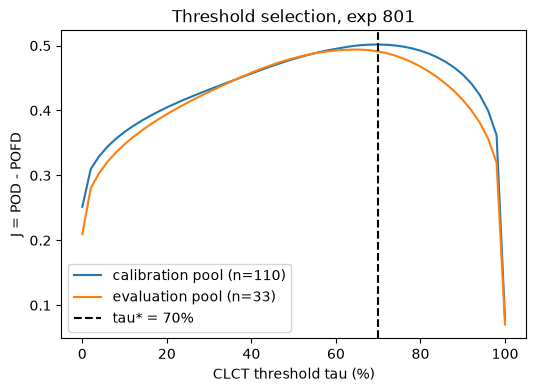

tau* chosen on calibration : 70%
J(tau*) on calibration     : 0.502
J(tau*) on evaluation      : 0.491   (POD=0.795, POFD=0.304)
best J achievable on evaluation: 0.494 at tau = 64% -- the gap to J(tau*) is the cost of not fitting in-sample


In [6]:
def contingency_j(clct, cma, tau):
    m = np.isfinite(clct) & np.isfinite(cma)
    pred = clct[m] > tau
    obs = cma[m] == 1
    hits = np.sum(pred & obs)
    misses = np.sum(~pred & obs)
    false_alarms = np.sum(pred & ~obs)
    correct_neg = np.sum(~pred & ~obs)
    pod = hits / (hits + misses) if (hits + misses) > 0 else np.nan
    pofd = false_alarms / (false_alarms + correct_neg) if (false_alarms + correct_neg) > 0 else np.nan
    return pod - pofd, pod, pofd


taus = np.arange(0, 101, 2)
J_calib = np.array([contingency_j(CLCT[CALIB], CMA[CALIB], tau)[0] for tau in taus])
J_eval = np.array([contingency_j(CLCT[EVAL], CMA[EVAL], tau)[0] for tau in taus])

tau_star = int(taus[np.nanargmax(J_calib)])
j_eval, pod_eval, pofd_eval = contingency_j(CLCT[EVAL], CMA[EVAL], tau_star)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(taus, J_calib, label=f"calibration pool (n={int(CALIB.sum())})")
ax.plot(taus, J_eval, label=f"evaluation pool (n={int(EVAL.sum())})")
ax.axvline(tau_star, color="k", ls="--", label=f"tau* = {tau_star}%")
ax.set_xlabel("CLCT threshold tau (%)")
ax.set_ylabel("J = POD - POFD")
ax.legend()
ax.set_title(f"Threshold selection, exp {EXP}")
plt.show()

print(f"tau* chosen on calibration : {tau_star}%")
print(f"J(tau*) on calibration     : {np.nanmax(J_calib):.3f}")
print(f"J(tau*) on evaluation      : {j_eval:.3f}   "
      f"(POD={pod_eval:.3f}, POFD={pofd_eval:.3f})")
print(f"best J achievable on evaluation: {np.nanmax(J_eval):.3f} at "
      f"tau = {int(taus[np.nanargmax(J_eval)])}% -- the gap to J(tau*) is the "
      f"cost of not fitting in-sample")

## 6. Method 4b — Fractions Skill Score

Roberts & Lean (2008), *Mon. Wea. Rev.* 136, 78-97 (FSS); Mittermaier & Roberts (2010), *Wea. Forecasting*
25, 343-354 (the per-cell skillful-scale map, implemented below instead of a single domain-wide score).
Both fields are box-averaged over a square neighbourhood and compared as fraction fields.

**Neighbourhoods are labelled by window side length**, which is Roberts & Lean's `n` — a "27 km window"
is a 9x9-cell box, 27 km across. Labelling by radius instead would understate every scale by about a
factor of two.

**Two forecast variants are scored**, because the choice matters a lot here:

- *continuous CLCT fraction* — CLCT/100 fed in directly. Defensible, since CLCT already is an areal cloud
  fraction, and it uses all the information the model provides. It is not the published method, though,
  and it inflates the score: the model's partial cloudiness partly matches the neighbourhood fraction of
  a binary mask even where the model would never have declared cloud.
- *CLCT binarised at tau\** — both fields binary before averaging, as in the original paper, using the
  threshold from section 5.

The useful-skill reference `FSS > 0.5 + f_obs/2` was designed with relatively rare events in mind. Cloud
is anything but rare here (`f_obs` around 0.6), which compresses all FSS values towards 1 and makes the
threshold easy to clear — worth remembering before reading the skillful-scale map as good news.

NWCSAF cell size: 2.97 x 3.00 km


observed cloud fraction on the evaluation pool: 0.621  (useful-skill reference FSS > 0.811)


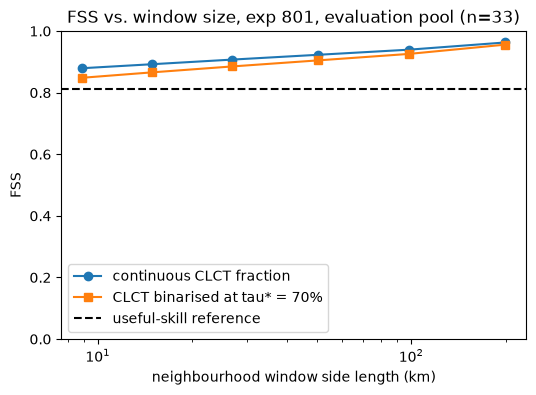

    window   cells   continuous    binarised
        9 km      3        0.879*       0.848*
       15 km      5        0.892*       0.866*
       27 km      9        0.907*       0.885*
       51 km     17        0.923*       0.905*
       98 km     33        0.939*       0.926*
      199 km     67        0.963*       0.956*
* exceeds the useful-skill reference


In [7]:
CELL_KM_X = abs(dlon) * 111.32 * np.cos(np.deg2rad(np.mean(lat)))
CELL_KM_Y = abs(dlat) * 111.32
print(f"NWCSAF cell size: {CELL_KM_X:.2f} x {CELL_KM_Y:.2f} km")


def odd_window_cells(km):
    """Window side length in cells, forced odd so the box stays centred."""
    s = max(1, int(round(km / CELL_KM_X)))
    return s if s % 2 == 1 else s + 1


def fss(mod_frac, obs_frac, side_cells):
    """Fractions Skill Score for one neighbourhood window. Both inputs are
    fractions in [0,1] on the same grid, shaped (time, y, x); the box average
    is spatial only, and all timesteps are pooled into one score."""
    size = (1, side_cells, side_cells) if mod_frac.ndim == 3 else (side_cells, side_cells)
    M = nan_uniform(mod_frac, size=size)
    O = nan_uniform(obs_frac, size=size)
    m = np.isfinite(M) & np.isfinite(O)
    mse = np.mean((M[m] - O[m]) ** 2)
    ref = np.mean(M[m] ** 2) + np.mean(O[m] ** 2)
    return 1 - mse / ref if ref > 0 else np.nan


WINDOWS_KM = [9, 15, 27, 51, 99, 195]
window_cells = [odd_window_cells(km) for km in WINDOWS_KM]
window_km = [s * CELL_KM_X for s in window_cells]   # actual, after rounding

cma_frac = keep_nan(CMA == 1, CMA)                  # observation, 0/1
clct_frac = CLCT / 100.0                            # ICON's own areal fraction
clct_bin = keep_nan(CLCT > tau_star, CLCT)          # binarised at tau* (section 5)

f_obs = float(np.nanmean(cma_frac[EVAL]))
skill_threshold = 0.5 + f_obs / 2
print(f"observed cloud fraction on the evaluation pool: {f_obs:.3f}  "
      f"(useful-skill reference FSS > {skill_threshold:.3f})")

FSS_cont = [fss(clct_frac[EVAL], cma_frac[EVAL], s) for s in window_cells]
FSS_bin = [fss(clct_bin[EVAL], cma_frac[EVAL], s) for s in window_cells]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(window_km, FSS_cont, marker="o", label="continuous CLCT fraction")
ax.plot(window_km, FSS_bin, marker="s", label=f"CLCT binarised at tau* = {tau_star}%")
ax.axhline(skill_threshold, color="k", ls="--", label="useful-skill reference")
ax.set_xscale("log")
ax.set_xlabel("neighbourhood window side length (km)")
ax.set_ylabel("FSS")
ax.set_ylim(0, 1)
ax.set_title(f"FSS vs. window size, exp {EXP}, evaluation pool "
             f"(n={int(EVAL.sum())})")
ax.legend()
plt.show()

print(f"{'window':>10s} {'cells':>7s} {'continuous':>12s} {'binarised':>12s}")
for km, s, fc, fb in zip(window_km, window_cells, FSS_cont, FSS_bin):
    print(f"{km:9.0f} km {s:6d}  {fc:11.3f}{'*' if fc > skill_threshold else ' '} "
          f"{fb:11.3f}{'*' if fb > skill_threshold else ' '}")
print("* exceeds the useful-skill reference")

local FSS pooled over 21 x 21 cells (62 km) and 33 timesteps


cells inside the domain never reaching the reference up to 199 km: 4201/131745


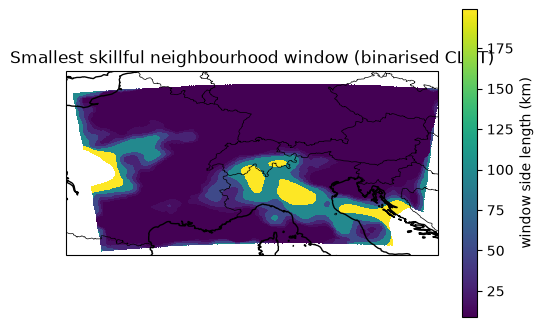

In [8]:
# Per-cell skillful scale (Mittermaier & Roberts 2010): the smallest window at
# which a *local* FSS -- pooled over a moving box and over every evaluation
# timestep -- exceeds the useful-skill reference. Computed with the binarised
# CLCT, i.e. the published form of the score; the continuous variant clears the
# reference almost everywhere at the smallest window, which leaves nothing to map.
POOL_KM = 60                      # side length of the local-FSS pooling box
pool_cells = odd_window_cells(POOL_KM)
print(f"local FSS pooled over {pool_cells} x {pool_cells} cells "
      f"({pool_cells * CELL_KM_X:.0f} km) and {int(EVAL.sum())} timesteps")


def local_fss_map(mod_frac, obs_frac, side_cells, pool_cells):
    size_L = (1, side_cells, side_cells) if mod_frac.ndim == 3 else (side_cells, side_cells)
    M = nan_uniform(mod_frac, size=size_L)
    O = nan_uniform(obs_frac, size=size_L)
    sq_err = (M - O) ** 2
    ref = M ** 2 + O ** 2

    size_W = (1, pool_cells, pool_cells) if mod_frac.ndim == 3 else (pool_cells, pool_cells)
    mse_local = nan_uniform(sq_err, size=size_W)
    ref_local = nan_uniform(ref, size=size_W)
    if mod_frac.ndim == 3:
        mse_local = nanmean_time(mse_local)
        ref_local = nanmean_time(ref_local)
    # ref_local == 0 means neither field has any cloud anywhere in the pooling
    # box: a perfect match, but FSS is undefined there, so it stays NaN
    with np.errstate(invalid="ignore", divide="ignore"):
        out = 1 - mse_local / ref_local
    return np.where(ref_local > 0, out, np.nan)


skillful_scale = np.full(shape, np.nan)
still_unresolved = np.ones(shape, dtype=bool)
for km, s in zip(window_km, window_cells):
    fss_map = local_fss_map(clct_bin[EVAL], cma_frac[EVAL], s, pool_cells)
    newly_skillful = still_unresolved & (fss_map > skill_threshold)
    skillful_scale[newly_skillful] = km
    still_unresolved &= ~newly_skillful

n_never = int(np.sum(still_unresolved & in_domain))
print(f"cells inside the domain never reaching the reference up to "
      f"{window_km[-1]:.0f} km: {n_never}/{int(in_domain.sum())}")

fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={"projection": ccrs.PlateCarree()})
mesh = ax.pcolormesh(lon, lat, np.where(in_domain, skillful_scale, np.nan),
                     transform=ccrs.PlateCarree(), cmap="viridis", shading="nearest")
ax.coastlines("10m")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
fig.colorbar(mesh, ax=ax, shrink=0.8, label="window side length (km)")
ax.set_title("Smallest skillful neighbourhood window (binarised CLCT)")
plt.show()

## 7. Method 4a — smoothed observation + Brier score decomposition

Brooks, Doswell & Cooper (1998), *Wea. Forecasting* 13, 1148-1164 (Gaussian smoothing of binary
occurrence data into a "practically perfect" probability); Murphy (1973), *J. Appl. Meteor.* 12, 595-600
(the Brier score decomposition). CMA carries no sub-pixel information to average the way a
finer-resolution truth would, so it is smoothed instead — in space, and optionally in time — turning single
bits into a continuous local cloud probability `p_obs` that CLCT/100 can be scored against directly, with no
thresholding on either side. How wide that smoothing should be is not obvious and matters for the score, so
it is swept in 7a and settled in 7b rather than assumed.

This needs NWCSAF at its native 15-minute cadence, loaded separately below over the span of `TIMES_used`.

In [9]:
n_steps = int((TIMES_used[-1] - TIMES_used[0]).total_seconds() // 900) + 1
fine_times = [TIMES_used[0] + timedelta(minutes=15 * k) for k in range(n_steps)]

cma_fine_list, fine_times_used = [], []
for t in fine_times:
    try:
        _, _, _, _, c = read_target(nwcsaf_file(t), DOMAIN)
    except Exception as e:
        print(f"  skip {t}: {type(e).__name__}")
        continue
    cma_fine_list.append(c)
    fine_times_used.append(t)
cma_fine = np.stack(cma_fine_list)
cma_fine[:, ~in_domain] = np.nan        # same footprint as CMA, see section 2
print(f"loaded {len(fine_times_used)}/{len(fine_times)} 15-min NWCSAF steps "
      f"({fine_times_used[0]} .. {fine_times_used[-1]})")

  skip 2025-10-06 12:00:00: FileNotFoundError
  skip 2025-10-06 12:15:00: FileNotFoundError


loaded 571/573 15-min NWCSAF steps (2025-10-04 01:00:00 .. 2025-10-10 00:00:00)


### 7a. Choosing the smoothing widths

The two smoothing widths are not free of consequences for the score. Smoothing reduces the variance of
`p_obs`, and that variance *is* the `uncertainty` term of the decomposition, which is the denominator of
the skill score `BSS = 1 - BS/uncertainty`. A wider kernel therefore makes the problem look easier and
inflates apparent skill with no change to the model whatsoever. The reference point is the unsmoothed
mask: a strictly binary observation with base rate `f` has uncertainty `f (1 - f)`, printed below for the
swept steps, and any value well under that is observed variance the smoothing has removed.

So both widths are swept on the calibration pool and the whole decomposition is printed for each
combination, `sigma_time = 0` (spatial smoothing only) included as the baseline. The sweep is restricted
to the calibration days before the date split, which are contiguous in time, so the time smoothing has no
gap inside its kernel.

In [10]:
def brier_decomposition(fcst, obs, n_bins=10):
    """Murphy (1973): BS = reliability - resolution + uncertainty. `obs` here is
    a smoothed probability rather than a strict 0/1 outcome, so `uncertainty` is
    the generalized Var(obs) -- which reduces to the classic o*(1-o) when the
    observation is binary. Bins are forecast deciles."""
    fcst = np.asarray(fcst).ravel()
    obs = np.asarray(obs).ravel()

    edges = np.quantile(fcst, np.linspace(0, 1, n_bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    bin_idx = np.digitize(fcst, edges[1:-1])

    obs_mean = obs.mean()
    uncertainty = np.mean((obs - obs_mean) ** 2)

    reliability = resolution = 0.0
    bin_f, bin_o, bin_n = [], [], []
    for k in range(n_bins):
        sel = bin_idx == k
        nk = int(sel.sum())
        if nk == 0:
            continue
        fk, ok = fcst[sel].mean(), obs[sel].mean()
        reliability += nk * (fk - ok) ** 2
        resolution += nk * (ok - obs_mean) ** 2
        bin_f.append(fk)
        bin_o.append(ok)
        bin_n.append(nk)

    n = fcst.size
    reliability /= n
    resolution /= n
    bs = float(np.mean((fcst - obs) ** 2))
    return dict(bs=bs, reliability=reliability, resolution=resolution,
                uncertainty=uncertainty,
                bs_decomp=reliability - resolution + uncertainty,
                bss=1 - bs / uncertainty if uncertainty > 0 else np.nan,
                obs_mean=obs_mean, n=n,
                bin_f=np.array(bin_f), bin_o=np.array(bin_o),
                bin_n=np.array(bin_n))


SIGMA_SPACE_LIST = [0.5, 1.0, 1.5, 2.5]   # cells (~3 km each)
SIGMA_TIME_LIST = [0, 2, 4, 8]            # 15-min steps

# contiguous calibration block: the days before the date split
fine_calib = np.array([t < SPLIT_DATE for t in fine_times_used])
cma_fine_calib = cma_fine[fine_calib]
ft_calib = [t for t, k in zip(fine_times_used, fine_calib) if k]
hours_calib = [t for t in TIMES_used if t < SPLIT_DATE and t in ft_calib]
idx_fine = [ft_calib.index(t) for t in hours_calib]
clct_calib = np.stack([CLCT[TIMES_used.index(t)] for t in hours_calib]) / 100.0
print(f"sweep on {len(hours_calib)} hourly steps "
      f"({hours_calib[0]} .. {hours_calib[-1]}), "
      f"{len(ft_calib)} 15-min steps behind them")

base = float(np.nanmean(cma_fine_calib[idx_fine]))
print(f"cloud base rate on those steps: {base:.3f} -> unsmoothed (binary) "
      f"uncertainty would be {base * (1 - base):.3f}\n")

print(f"{'s_time':>7s} {'s_space':>8s} {'BS':>8s} {'reliab':>8s} {'resol':>8s} "
      f"{'uncert':>8s} {'BSS':>8s}")
for st in SIGMA_TIME_LIST:
    for ss in SIGMA_SPACE_LIST:
        p = nan_gaussian(cma_fine_calib, sigma=(st, ss, ss))[idx_fine]
        m = np.isfinite(clct_calib) & np.isfinite(p)
        dd = brier_decomposition(clct_calib[m], p[m])
        print(f"{st:7d} {ss:8.1f} {dd['bs']:8.4f} {dd['reliability']:8.4f} "
              f"{dd['resolution']:8.4f} {dd['uncertainty']:8.4f} {dd['bss']:8.3f}")

sweep on 70 hourly steps (2025-10-04 01:00:00 .. 2025-10-06 23:00:00), 282 15-min steps behind them
cloud base rate on those steps: 0.584 -> unsmoothed (binary) uncertainty would be 0.243

 s_time  s_space       BS   reliab    resol   uncert      BSS


      0      0.5   0.1506   0.0128   0.0877   0.2259    0.334


      0      1.0   0.1307   0.0130   0.0874   0.2056    0.364


      0      1.5   0.1208   0.0131   0.0871   0.1952    0.381


      0      2.5   0.1085   0.0134   0.0862   0.1817    0.403


...

      4      2.5   0.0812   0.0150   0.0817   0.1482    0.452


      8      0.5   0.0776   0.0174   0.0755   0.1359    0.429


      8      1.0   0.0762   0.0175   0.0753   0.1343    0.432


      8      1.5   0.0755   0.0176   0.0750   0.1332    0.433


      8      2.5   0.0744   0.0179   0.0745   0.1312    0.433


### 7b. The chosen widths

**`sigma_space` = 1 cell (~3 km), `sigma_time` = 0 (no time smoothing).**

The sweep shows what is at stake. BSS rises monotonically from 0.33 to 0.45 across the table without the
forecast changing at all, entirely because its denominator `uncertainty` falls from 0.226 to 0.131 against
0.243 for the unsmoothed binary mask. Reliability and resolution move much less over the same range
(0.013 → 0.018 and 0.088 → 0.075), so wider kernels buy very little diagnostic information and cost a lot
of interpretability. That argues for the smallest widths that still serve the purpose of the method.

One cell of spatial smoothing is the scale of the comparison itself: it grants the model tolerance at the
size of the grid cells the two fields live on, and no more. Granting tolerance at larger scales is exactly
what a neighbourhood method does, and that is section 6's job — 4a should not quietly turn into a second
FSS with an unstated neighbourhood size.

`sigma_time = 0` because there is no timing mismatch to absorb: `lff` CLCT is instantaneous and valid on the
hour, and the satellite slot it is paired with is within minutes of it. Time smoothing would suppress
genuine short-term variability along with detection noise, and it is much the more expensive of the two
knobs — going from 0 to 8 steps (2 h) removes 40% of the observed variance and adds 0.10 to BSS on its own.

Two consequences, stated rather than hidden. The retained `uncertainty` ends up about a sixth below the
binary value, so the BSS reported below is mildly flattered, and the table above is the record of how much more
flattering other choices would have been. And with no time smoothing the 15-minute cadence loaded above is
used only by the sweep; the score itself needs the hourly slices alone. That is the price of being able to
sweep at all.

smoothing p_obs with sigma_space = 1.0 cells (~3.0 km) and sigma_time = 0 steps (~0 min)


scoring 33 evaluation timesteps


Brier score (direct)       : 0.1403
Brier score (decomposed)   : 0.1410  (gap 0.0006, 0.5% of BS -- the within-bin terms the three-term form drops)
  reliability (want small) : 0.0151
  resolution  (want large) : 0.0699
  uncertainty (base rate)  : 0.1958  (binary equivalent 0.2354)
  BSS = 1 - BS/uncertainty : 0.283


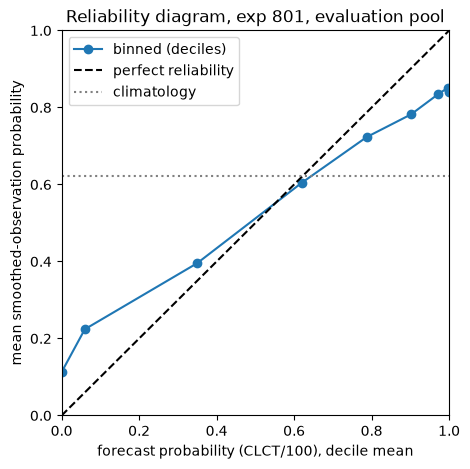

In [11]:
SIGMA_SPACE_CELLS = 1.0   # cells, ~3 km each -- chosen above
SIGMA_TIME_STEPS = 0      # 15-min steps; 0 = spatial smoothing only

print(f"smoothing p_obs with sigma_space = {SIGMA_SPACE_CELLS} cells "
      f"(~{SIGMA_SPACE_CELLS * CELL_KM_X:.1f} km) and sigma_time = "
      f"{SIGMA_TIME_STEPS} steps (~{SIGMA_TIME_STEPS * 15} min)")

p_obs_fine = nan_gaussian(cma_fine, sigma=(SIGMA_TIME_STEPS, SIGMA_SPACE_CELLS,
                                           SIGMA_SPACE_CELLS))

eval_times = [t for t, k in zip(TIMES_used, EVAL) if k and t in fine_times_used]
p_obs_eval = p_obs_fine[[fine_times_used.index(t) for t in eval_times]]
clct_eval = np.stack([CLCT[TIMES_used.index(t)] for t in eval_times]) / 100.0
print(f"scoring {len(eval_times)} evaluation timesteps")

m = np.isfinite(clct_eval) & np.isfinite(p_obs_eval)
brier_eval = brier_decomposition(clct_eval[m], p_obs_eval[m])

# BS (direct) and BS (decomposed) do not agree exactly, and that is expected
# rather than a bug: the classical three-term decomposition assumes the forecast
# probability is constant inside each subset, so binning a *continuous* forecast
# drops within-bin variance terms. Stephenson et al. (2008), "Two extra
# components in the Brier score decomposition", adds them back explicitly.
print(f"Brier score (direct)       : {brier_eval['bs']:.4f}")
print(f"Brier score (decomposed)   : {brier_eval['bs_decomp']:.4f}  "
      f"(gap {abs(brier_eval['bs'] - brier_eval['bs_decomp']):.4f}, "
      f"{100 * abs(brier_eval['bs'] - brier_eval['bs_decomp']) / brier_eval['bs']:.1f}% of BS -- "
      f"the within-bin terms the three-term form drops)")
print(f"  reliability (want small) : {brier_eval['reliability']:.4f}")
print(f"  resolution  (want large) : {brier_eval['resolution']:.4f}")
print(f"  uncertainty (base rate)  : {brier_eval['uncertainty']:.4f}  "
      f"(binary equivalent {brier_eval['obs_mean'] * (1 - brier_eval['obs_mean']):.4f})")
print(f"  BSS = 1 - BS/uncertainty : {brier_eval['bss']:.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(brier_eval["bin_f"], brier_eval["bin_o"], "o-", label="binned (deciles)")
ax.plot([0, 1], [0, 1], "k--", label="perfect reliability")
ax.axhline(brier_eval["obs_mean"], color="gray", ls=":", label="climatology")
ax.set_xlabel("forecast probability (CLCT/100), decile mean")
ax.set_ylabel("mean smoothed-observation probability")
ax.set_title(f"Reliability diagram, exp {EXP}, evaluation pool")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.show()

## 8. Method 4d — SAL (structure, amplitude, location)

Wernli, Paulat, Hagen & Frei (2008), *Mon. Wea. Rev.* 136, 4470-4487; applied to exactly this kind of
comparison (satellite cloud mask against NWP) by Crocker & Mittermaier (2013), *Meteorol. Appl.* 20,
197-205.

FSS says at which spatial scale the forecast becomes trustworthy, but not what is wrong below that scale.
SAL splits the disagreement into three numbers that point at different model behaviour:

- **A — amplitude**: the normalised difference in domain-mean cloud, `A = (mean_mod - mean_obs) /
  (0.5 (mean_mod + mean_obs))`, in [-2, 2]. Positive means too much cloud in total, regardless of where.
- **L — location**: `L = L1 + L2`. `L1` is the distance between the centres of mass of the two fields
  divided by the domain diagonal `d`. `L2 = 2 |r_mod - r_obs| / d` compares how far the cloud objects sit
  from that centre of mass on average (`r` = object-total-weighted mean distance of the objects from the
  field's centre of mass), which catches cases where the centres coincide but the distributions differ.
  Both in [0, 1].
- **S — structure**: for each object, the scaled volume `V_n = R_n / max(R_n)` where `R_n` is the object's
  summed field value; `V` is the object-total-weighted mean of `V_n`, and
  `S = (V_mod - V_obs) / (0.5 (V_mod + V_obs))`, in [-2, 2]. Positive means the model's objects are too
  large, too flat, too smeared out; negative means too small, too peaked, too fragmented.

A perfect forecast has S = A = 0 and L = 0. All three are computed per timestep, and the distribution
across timesteps is what gets reported — SAL compares aggregate object properties, so there is no object
matching and no MODE-style machinery involved.

**Objects.** Wernli et al. threshold precipitation at `R_max/15`, which does not transfer to a cloud mask
whose maximum is always 1. Instead: observed objects are simply the contiguous regions where `CMA == 1`,
and model objects are the contiguous regions where CLCT exceeds `tau*` from section 5. This keeps the two
fields consistently defined and reuses a threshold that was already justified out of sample instead of
inventing a new one. Connected components use `scipy.ndimage.label` with its default 4-connectivity.
Inside the objects the fields keep their original values, so a partly cloudy ICON object contributes less
volume than a solidly overcast one.

This is where ICON's hedging should show up. `tau*` landed at a high CLCT value, which means a lot of
partial cloudiness sits in places the satellite calls clear; if those partial-cloud areas are large and
flat compared with the satellite's cloud fields, S should come out positive.

In [12]:
def sal_components(mod, obs, thr_mod, thr_obs, dx_km, dy_km):
    """Structure, amplitude and location for one timestep (Wernli et al. 2008).

    mod, obs         non-negative 2-D fields on the same grid, NaN where the
                     domain is undefined (regridding edges, missing pixels).
                     Cells that are NaN in either field are excluded from the
                     domain entirely, for both fields.
    thr_mod, thr_obs value a cell must exceed to belong to an object.

    Returns None if either field contains no object at all.
    """
    valid = np.isfinite(mod) & np.isfinite(obs)
    if not valid.any():
        return None

    ny, nx = mod.shape
    yy, xx = np.meshgrid(np.arange(ny) * dy_km, np.arange(nx) * dx_km,
                         indexing="ij")

    # `d`, the largest distance between two points of the domain: the diagonal
    # of the bounding box of the valid cells
    iy, ix = np.where(valid)
    d = float(np.hypot((ix.max() - ix.min()) * dx_km,
                       (iy.max() - iy.min()) * dy_km))

    def stats(f, thr):
        f = np.where(valid, f, 0.0)      # cells outside the domain carry no weight
        total = f.sum()
        if total <= 0:
            return None
        lab, n_obj = ndimage.label(f > thr)     # 4-connectivity (scipy default)
        if n_obj == 0:
            return None
        idx = np.arange(1, n_obj + 1)
        R_n = np.asarray(ndimage.sum(f, lab, idx), dtype=float)
        R_max = np.asarray(ndimage.maximum(f, lab, idx), dtype=float)
        ox = np.asarray(ndimage.sum(f * xx, lab, idx), dtype=float) / R_n
        oy = np.asarray(ndimage.sum(f * yy, lab, idx), dtype=float) / R_n
        # centre of mass of the whole field, not just of the objects
        cx = float((f * xx).sum() / total)
        cy = float((f * yy).sum() / total)
        return dict(mean=total / valid.sum(), cx=cx, cy=cy, n_obj=n_obj,
                    V=float((R_n * (R_n / R_max)).sum() / R_n.sum()),
                    r=float((R_n * np.hypot(ox - cx, oy - cy)).sum() / R_n.sum()))

    a, b = stats(mod, thr_mod), stats(obs, thr_obs)
    if a is None or b is None:
        return None

    A = (a["mean"] - b["mean"]) / (0.5 * (a["mean"] + b["mean"]))
    S = (a["V"] - b["V"]) / (0.5 * (a["V"] + b["V"]))
    L1 = float(np.hypot(a["cx"] - b["cx"], a["cy"] - b["cy"]) / d)
    L2 = 2 * abs(a["r"] - b["r"]) / d
    return dict(S=S, A=A, L1=L1, L2=L2, L=L1 + L2, d_km=d,
                n_obj_mod=a["n_obj"], n_obj_obs=b["n_obj"])


sal_rows, sal_skipped = [], []
for i, t in enumerate(TIMES_used):
    if not EVAL[i]:
        continue
    r = sal_components(CLCT[i] / 100.0, keep_nan(CMA[i] == 1, CMA[i]),
                       tau_star / 100.0, 0.5, CELL_KM_X, CELL_KM_Y)
    if r is None:
        sal_skipped.append(t)
        print(f"  {t:%Y-%m-%d %H} UTC: one of the fields has no object, skipped")
        continue
    r["time"] = t
    sal_rows.append(r)
    print(f"  {t:%Y-%m-%d %H} UTC  S={r['S']:+.2f}  A={r['A']:+.2f}  "
          f"L={r['L']:.3f} (L1={r['L1']:.3f} L2={r['L2']:.3f})  "
          f"objects: ICON {r['n_obj_mod']:4d}, satellite {r['n_obj_obs']:4d}")

S = np.array([r["S"] for r in sal_rows])
A = np.array([r["A"] for r in sal_rows])
L = np.array([r["L"] for r in sal_rows])
print(f"\n{len(sal_rows)} evaluation timesteps scored, {len(sal_skipped)} skipped; "
      f"domain diagonal d = {sal_rows[0]['d_km']:.0f} km")
print(f"objects per timestep: ICON median "
      f"{np.median([r['n_obj_mod'] for r in sal_rows]):.0f}, satellite median "
      f"{np.median([r['n_obj_obs'] for r in sal_rows]):.0f}")

  2025-10-07 06 UTC  S=+1.06  A=+0.25  L=0.436 (L1=0.030 L2=0.405)  objects: ICON  344, satellite  314
  2025-10-07 07 UTC  S=+0.00  A=+0.09  L=0.078 (L1=0.042 L2=0.035)  objects: ICON  275, satellite  277
  2025-10-07 08 UTC  S=-0.14  A=+0.06  L=0.093 (L1=0.039 L2=0.055)  objects: ICON  318, satellite  300


  2025-10-07 09 UTC  S=+0.15  A=+0.03  L=0.121 (L1=0.038 L2=0.083)  objects: ICON  457, satellite  302
  2025-10-07 10 UTC  S=-0.18  A=+0.03  L=0.078 (L1=0.053 L2=0.025)  objects: ICON  470, satellite  350
  2025-10-07 11 UTC  S=-0.17  A=+0.04  L=0.089 (L1=0.064 L2=0.025)  objects: ICON  457, satellite  362
  2025-10-07 12 UTC  S=-0.18  A=+0.03  L=0.066 (L1=0.066 L2=0.000)  objects: ICON  466, satellite  309
  2025-10-07 13 UTC  S=-0.21  A=+0.07  L=0.128 (L1=0.071 L2=0.056)  objects: ICON  453, satellite  304
  2025-10-07 14 UTC  S=-0.19  A=+0.08  L=0.133 (L1=0.072 L2=0.060)  objects: ICON  397, satellite  270


  2025-10-07 15 UTC  S=-0.01  A=+0.11  L=0.102 (L1=0.073 L2=0.029)  objects: ICON  396, satellite  277
  2025-10-07 16 UTC  S=+0.89  A=+0.39  L=0.239 (L1=0.050 L2=0.189)  objects: ICON  394, satellite  354


  2025-10-08 06 UTC  S=+1.23  A=+0.48  L=0.290 (L1=0.042 L2=0.248)  objects: ICON  605, satellite  493
  2025-10-08 07 UTC  S=+0.63  A=+0.25  L=0.242 (L1=0.047 L2=0.195)  objects: ICON  491, satellite  435
  2025-10-08 08 UTC  S=+0.39  A=+0.19  L=0.165 (L1=0.029 L2=0.136)  objects: ICON  380, satellite  341
  2025-10-08 09 UTC  S=+0.42  A=+0.19  L=0.182 (L1=0.027 L2=0.155)  objects: ICON  416, satellite  353
  2025-10-08 10 UTC  S=+0.49  A=+0.18  L=0.208 (L1=0.029 L2=0.179)  objects: ICON  421, satellite  356
  2025-10-08 11 UTC  S=+0.11  A=+0.17  L=0.039 (L1=0.027 L2=0.012)  objects: ICON  385, satellite  323


  2025-10-08 12 UTC  S=+0.12  A=+0.15  L=0.036 (L1=0.024 L2=0.012)  objects: ICON  392, satellite  320
  2025-10-08 13 UTC  S=+0.22  A=+0.17  L=0.041 (L1=0.022 L2=0.019)  objects: ICON  429, satellite  321


  2025-10-08 14 UTC  S=+0.15  A=+0.15  L=0.035 (L1=0.017 L2=0.018)  objects: ICON  374, satellite  268
  2025-10-08 15 UTC  S=+0.11  A=+0.14  L=0.028 (L1=0.015 L2=0.013)  objects: ICON  333, satellite  225
  2025-10-08 16 UTC  S=+0.20  A=+0.18  L=0.056 (L1=0.018 L2=0.039)  objects: ICON  219, satellite  178
  2025-10-09 06 UTC  S=+0.12  A=+0.17  L=0.015 (L1=0.015 L2=0.000)  objects: ICON  284, satellite  296
  2025-10-09 07 UTC  S=-0.10  A=-0.00  L=0.012 (L1=0.010 L2=0.002)  objects: ICON  348, satellite  151
  2025-10-09 08 UTC  S=-0.21  A=-0.05  L=0.054 (L1=0.020 L2=0.035)  objects: ICON  335, satellite  137
  2025-10-09 09 UTC  S=-0.34  A=-0.06  L=0.119 (L1=0.015 L2=0.104)  objects: ICON  465, satellite  141
  2025-10-09 10 UTC  S=-0.32  A=-0.07  L=0.104 (L1=0.016 L2=0.088)  objects: ICON  495, satellite  162


  2025-10-09 11 UTC  S=-0.27  A=-0.09  L=0.052 (L1=0.015 L2=0.037)  objects: ICON  540, satellite  188
  2025-10-09 12 UTC  S=-0.28  A=-0.10  L=0.044 (L1=0.013 L2=0.030)  objects: ICON  615, satellite  152


  2025-10-09 13 UTC  S=-0.31  A=-0.11  L=0.062 (L1=0.015 L2=0.047)  objects: ICON  765, satellite  132
  2025-10-09 14 UTC  S=-0.37  A=-0.13  L=0.075 (L1=0.012 L2=0.063)  objects: ICON  897, satellite  104
  2025-10-09 15 UTC  S=-0.50  A=-0.10  L=0.169 (L1=0.008 L2=0.161)  objects: ICON  865, satellite  105
  2025-10-09 16 UTC  S=-0.02  A=+0.14  L=0.041 (L1=0.020 L2=0.021)  objects: ICON  791, satellite  342

33 evaluation timesteps scored, 0 skipped; domain diagonal d = 1690 km
objects per timestep: ICON median 421, satellite median 300


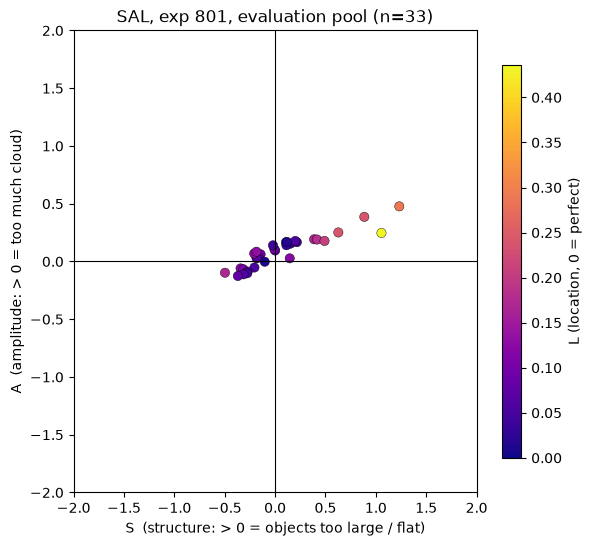

S: median -0.007   IQR [-0.205, +0.200]
A: median +0.095   IQR [-0.002, +0.170]
L: median +0.078   IQR [+0.044, +0.133]
L1: median 0.027, L2: median 0.039


In [13]:
fig, ax = plt.subplots(figsize=(6.5, 6))
sc = ax.scatter(S, A, c=L, cmap="plasma", vmin=0, edgecolor="k", linewidth=0.3, s=45)
ax.axhline(0, color="k", lw=0.8)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_xlabel("S  (structure: > 0 = objects too large / flat)")
ax.set_ylabel("A  (amplitude: > 0 = too much cloud)")
ax.set_title(f"SAL, exp {EXP}, evaluation pool (n={len(sal_rows)})")
fig.colorbar(sc, ax=ax, shrink=0.85, label="L (location, 0 = perfect)")
plt.show()


def med_iqr(v):
    q1, q3 = np.percentile(v, [25, 75])
    return np.median(v), q1, q3


for name, v in (("S", S), ("A", A), ("L", L)):
    m, q1, q3 = med_iqr(v)
    print(f"{name}: median {m:+.3f}   IQR [{q1:+.3f}, {q3:+.3f}]")
print(f"L1: median {np.median([r['L1'] for r in sal_rows]):.3f}, "
      f"L2: median {np.median([r['L2'] for r in sal_rows]):.3f}")

### What the SAL numbers say

Over the daytime evaluation steps: **A = +0.10** (IQR -0.00 to +0.17), **S = -0.01** (IQR -0.21 to +0.20),
**L = 0.08** (IQR 0.04 to 0.13, split into L1 = 0.03 and L2 = 0.04).

**Amplitude.** A median A of +0.10 means ICON carries roughly 10% more cloud than the satellite sees over
the domain. It is a small number, but consistently signed — the interquartile range barely reaches below
zero — and it points the same way as the positive CLCT bias this investigation is about.

**Location.** L is small: 0.08 of a 1690 km domain diagonal. The cloud is broadly where it should be. The
spread term L2 slightly exceeds the centre-of-mass term L1, so what location error exists comes more from
cloud being distributed differently inside the domain than from the whole field sitting in the wrong place.

**Structure, which is the surprise.** The median S is essentially zero, but the spread is wide and the sign
is organised by day rather than scattered at random:

- 8 October, and the first hour of 7 October: S between +0.4 and +1.2 — model objects larger and flatter
  than observed.
- 9 October: S between -0.2 and -0.5, with ICON finding 500-900 objects against the satellite's 100-160 —
  model cloud broken into far more and far smaller pieces than observed.

So the expectation that ICON's partial cloudiness would show up as systematically smeared-out cloud objects
is **not** confirmed. ICON does produce more objects than the satellite at almost every timestep (median
421 against 300), which is a fragmentation signature rather than a smearing one, yet the volume-weighted
structure metric swings from strongly positive to clearly negative between consecutive days. Whatever ICON
gets wrong about cloud structure here depends on the situation; it is not a fixed bias.

Two things to keep in mind before taking any of this further. The evaluation pool is three days of daytime
steps, an effective sample of well under ten, so the per-day signs above are probably describing two or
three weather situations rather than model behaviour in general. And the object counts are high in absolute
terms because a pixel-level mask genuinely is speckled; SAL weights each object by its total field value,
so the many single-pixel objects contribute almost nothing to S, but a threshold or a smoothing choice that
changed the speckle would still move the number.

## 9. Cross-cutting diagnostics

Two checks that apply to everything above: how much the day/night split matters (CMA quality depends
strongly on solar elevation, and the calibration pool is night-heavy by construction), and how many
genuinely independent samples the loaded period contains.

In [14]:
print(f"skill at tau* = {tau_star}% by illumination "
      f"(evaluation pool is daytime only by construction)")
for label, sel in (("day", is_day), ("night", ~is_day),
                   ("day, eval pool", EVAL), ("calibration", CALIB)):
    if sel.sum() == 0:
        continue
    j, pod, pofd = contingency_j(CLCT[sel], CMA[sel], tau_star)
    cloud = float(np.nanmean(keep_nan(CMA[sel] == 1, CMA[sel])))
    print(f"  {label:15s} (n={int(sel.sum()):4d}): J={j:.3f}  POD={pod:.3f}  "
          f"POFD={pofd:.3f}  observed cloud fraction={cloud:.3f}")

skill at tau* = 70% by illumination (evaluation pool is daytime only by construction)


  day             (n=  68): J=0.534  POD=0.783  POFD=0.248  observed cloud fraction=0.636


  night           (n=  75): J=0.479  POD=0.795  POFD=0.315  observed cloud fraction=0.511


  day, eval pool  (n=  33): J=0.491  POD=0.795  POFD=0.304  observed cloud fraction=0.621


  calibration     (n= 110): J=0.502  POD=0.786  POFD=0.284  observed cloud fraction=0.555


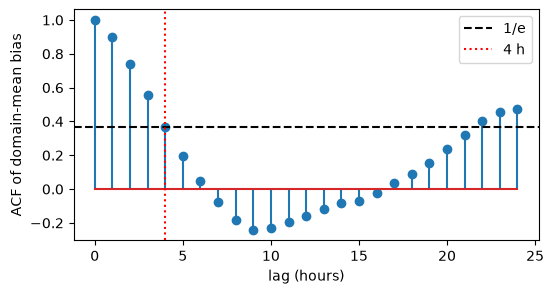

measured decorrelation time: 4 h
  all steps   :  143 hourly steps, 4 h decorrelation -> effective N ~ 36
  calibration :  110 hourly steps, 4 h decorrelation -> effective N ~ 28  ** WARNING: below 30 independent samples, differences between experiments are not meaningful at this size **
  evaluation  :   33 hourly steps, 4 h decorrelation -> effective N ~ 8  ** WARNING: below 30 independent samples, differences between experiments are not meaningful at this size **


In [15]:
# Decorrelation time from the ACF of the domain-mean bias series. This is what
# sets the effective sample size: hourly steps are not independent draws, so the
# apparent precision of every score above is optimistic.
bias_ts = np.array([
    np.nanmean(CLCT[i][np.isfinite(CMA[i])] / 100.0
              - (CMA[i][np.isfinite(CMA[i])] == 1))
    for i in range(len(TIMES_used))
])
bias_ts = bias_ts - np.nanmean(bias_ts)
n_lags = min(25, len(bias_ts) - 1)
acf = np.array([
    1.0 if k == 0 else np.corrcoef(bias_ts[:-k], bias_ts[k:])[0, 1]
    for k in range(n_lags)
])
DECORR_H = next((k for k, a in enumerate(acf) if a < 1 / np.e), len(acf))

fig, ax = plt.subplots(figsize=(6, 3))
ax.stem(range(len(acf)), acf)
ax.axhline(1 / np.e, color="k", ls="--", label="1/e")
ax.axvline(DECORR_H, color="r", ls=":", label=f"{DECORR_H} h")
ax.set_xlabel("lag (hours)")
ax.set_ylabel("ACF of domain-mean bias")
ax.legend()
plt.show()

print(f"measured decorrelation time: {DECORR_H} h")
for label, sel in (("all steps", np.ones_like(EVAL)), ("calibration", CALIB),
                   ("evaluation", EVAL)):
    report_effective_n(label, int(sel.sum()), DECORR_H)

## 10. Summary

Headline numbers, all from the evaluation pool (daytime from the date split on), with the effective sample
size behind them.

In [16]:
n_eval = int(EVAL.sum())
eff_eval = n_eval / max(DECORR_H, 1)

print("=" * 78)
print(f"exp {EXP}   {TIMES_used[0]:%Y-%m-%d %H} .. {TIMES_used[-1]:%Y-%m-%d %H} UTC   "
      f"grid {shape}, {int(in_domain.sum())} cells in domain")
print(f"pools: calibration {int(CALIB.sum())} steps (fitting only), "
      f"evaluation {n_eval} steps (daytime from {SPLIT_DATE:%Y-%m-%d})")
print(f"effective sample size of the evaluation pool: ~{eff_eval:.0f} "
      f"({DECORR_H} h decorrelation)"
      + ("   ** below "
         f"{MIN_EFFECTIVE_N}: do not read 801-vs-802 differences off these "
         "numbers **" if eff_eval < MIN_EFFECTIVE_N else ""))
print("-" * 78)
print(f"4c  threshold      tau* = {tau_star}% (fitted on calibration), "
      f"J = {j_eval:.3f} on evaluation")
print(f"                   POD = {pod_eval:.3f}, POFD = {pofd_eval:.3f}")
print(f"4b  FSS            observed cloud fraction {f_obs:.3f}, "
      f"useful-skill reference {skill_threshold:.3f}")
print(f"                   continuous CLCT: {FSS_cont[0]:.3f} at "
      f"{window_km[0]:.0f} km -> {FSS_cont[-1]:.3f} at {window_km[-1]:.0f} km")
print(f"                   binarised CLCT : {FSS_bin[0]:.3f} at "
      f"{window_km[0]:.0f} km -> {FSS_bin[-1]:.3f} at {window_km[-1]:.0f} km")
print(f"                   cells never skillful up to {window_km[-1]:.0f} km: "
      f"{n_never}/{int(in_domain.sum())}")
print(f"4a  Brier          BS = {brier_eval['bs']:.4f}, BSS = {brier_eval['bss']:.3f} "
      f"(sigma_space {SIGMA_SPACE_CELLS} cells, sigma_time {SIGMA_TIME_STEPS} steps)")
print(f"                   reliability {brier_eval['reliability']:.4f}, resolution "
      f"{brier_eval['resolution']:.4f}, uncertainty {brier_eval['uncertainty']:.4f}")
print(f"4d  SAL (median)   S = {np.median(S):+.3f}, A = {np.median(A):+.3f}, "
      f"L = {np.median(L):.3f}   over {len(sal_rows)} timesteps")
print("=" * 78)

exp 801   2025-10-04 01 .. 2025-10-10 00 UTC   grid (341, 482), 131745 cells in domain
pools: calibration 110 steps (fitting only), evaluation 33 steps (daytime from 2025-10-07)
effective sample size of the evaluation pool: ~8 (4 h decorrelation)   ** below 30: do not read 801-vs-802 differences off these numbers **
------------------------------------------------------------------------------
4c  threshold      tau* = 70% (fitted on calibration), J = 0.491 on evaluation
                   POD = 0.795, POFD = 0.304
4b  FSS            observed cloud fraction 0.621, useful-skill reference 0.811
                   continuous CLCT: 0.879 at 9 km -> 0.963 at 199 km
                   binarised CLCT : 0.848 at 9 km -> 0.956 at 199 km
                   cells never skillful up to 199 km: 4201/131745
4a  Brier          BS = 0.1403, BSS = 0.283 (sigma_space 1.0 cells, sigma_time 0 steps)
                   reliability 0.0151, resolution 0.0699, uncertainty 0.1958
4d  SAL (median)   S = -0.007, 

## Notes

**What is fitted where.** `tau*` (section 5) and the two smoothing widths (section 7a) are chosen on the
calibration pool — timesteps before the date split, plus all night timesteps. Every number quoted in
section 10 comes from the evaluation pool, which had no part in those choices. The remaining in-sample
element is the choice of window sizes in 4b and of the pooling box for the skillful-scale map; those are
fixed a priori rather than optimised, and section 6 prints the value of each.

**Known limitations, flagged rather than hidden.**
- *Parallax* — not corrected. See the header cell for the size and direction of the error and why it is
  out of scope; it affects the location-sensitive results (4b, 4c, SAL's L) in one direction.
- *Sample size* — the ACF of the domain-mean bias decays over a few hours, so a week of hourly steps is
  only a handful of independent samples. This is enough to characterise the comparison methods, and not
  enough to rank experiments 801 and 802 against each other. Section 9 prints the number; section 10
  repeats the warning.
- *Brier decomposition residual* — BS (direct) and BS (decomposed) differ by a small amount because
  binning a continuous forecast drops the within-bin variance terms that the classical three-term form
  assumes away. The gap is printed rather than silently tolerated.
- *FSS base rate* — cloud occurs in roughly 60% of pixels, far from the rare-event regime FSS was designed
  for, so all FSS values are compressed towards 1 and the useful-skill reference is easy to clear. The
  binarised variant is the honest comparison to the published method; the continuous variant scores higher
  because partial cloudiness partly matches a neighbourhood fraction even where the model would not have
  declared cloud.
- *Weather-regime stratification* — not implemented; only day/night is stratified.
- *Block bootstrap confidence intervals* — not implemented; the decorrelation-time diagnostic is the
  substitute, and it is a diagnostic, not an interval.
- *k-fold threshold cross-validation* — not implemented; a single calibration/evaluation split is used.

**Next steps.** Repeat with `EXP = "802"` for the T_2M/RH_2M-excluded run, keeping the sample-size caveat
in mind, and read the SAL components rather than the aggregate scores when asking *how* the two runs
differ.